In [35]:
import h5py
import numpy as np

In [36]:
f = h5py.File('models/grid_v0.1_ov0-plato.hdf5', 'r') 

print(list(f.keys()))


['grid_v0.1_ov0_001000', 'grid_v0.1_ov0_001002', 'grid_v0.1_ov0_001003', 'grid_v0.1_ov0_001006', 'grid_v0.1_ov0_001007', 'grid_v0.1_ov0_001008', 'grid_v0.1_ov0_001010', 'grid_v0.1_ov0_001012', 'grid_v0.1_ov0_001013', 'grid_v0.1_ov0_001014', 'grid_v0.1_ov0_001015', 'grid_v0.1_ov0_001018', 'grid_v0.1_ov0_001020', 'grid_v0.1_ov0_001021', 'grid_v0.1_ov0_001024', 'grid_v0.1_ov0_001025', 'grid_v0.1_ov0_001026', 'grid_v0.1_ov0_001027', 'grid_v0.1_ov0_001028', 'grid_v0.1_ov0_001030', 'grid_v0.1_ov0_001032', 'grid_v0.1_ov0_001034', 'grid_v0.1_ov0_001036', 'grid_v0.1_ov0_001037', 'grid_v0.1_ov0_001038', 'grid_v0.1_ov0_001040', 'grid_v0.1_ov0_001041', 'grid_v0.1_ov0_001042', 'grid_v0.1_ov0_001043', 'grid_v0.1_ov0_001044', 'grid_v0.1_ov0_001046', 'grid_v0.1_ov0_001048', 'grid_v0.1_ov0_001049', 'grid_v0.1_ov0_001051', 'grid_v0.1_ov0_001052', 'grid_v0.1_ov0_001054', 'grid_v0.1_ov0_001055', 'grid_v0.1_ov0_001056', 'grid_v0.1_ov0_001058', 'grid_v0.1_ov0_001060', 'grid_v0.1_ov0_001061', 'grid_v0.1_ov0_

In [37]:
dset = f['grid_v0.1_ov0_001002']
dset.keys()

<KeysViewHDF5 ['flags', 'global', 'input', 'osc', 'parameters']>

In [39]:
dset['flags'].keys()

<KeysViewHDF5 ['lmax', 'lmin', 'ncz', 'nmax', 'nmin', 'tcz_he']>

In [ ]:
dset['global'].keys()

<KeysViewHDF5 ['Xc', 'Y0', 'Z0', 'age', 'alpha', 'delta_nu', 'feh0', 'fehs', 'logg', 'lum', 'mass', 'mcz_core', 'mcz_env', 'numax', 'ovshts', 'radius', 'rcz_core', 'rcz_env', 'rhoav', 'rhoc', 'tcz_bcz', 'tcz_he', 'tcz_tot', 'teff', 'ys', 'z3s', 'zs']>

In [ ]:
dset['input'].keys()

<KeysViewHDF5 ['adipls', 'adipls_redistrib', 'don', 'evol_code', 'evol_revision', 'osc_code', 'osc_revision', 'run']>

In [46]:
dset['osc'].keys()

<KeysViewHDF5 ['0', '1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '11', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '12', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '13', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '14', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '15', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '16', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '17', '170', '171', '172', '173', '174', '175', '176', '177', '178', '179', '18', '180', '181', '182', '183', '184', '185', '186', '187', '188', '189', '19', '190', '191', '192', '193', '194', '195', '196', '197', '198', '199', '2', '20', '200', '201', '202', '203', '204', '205', '206', '207', '208', '209', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41'

In [ ]:
dset['parameters'].keys()

<KeysViewHDF5 ['Y0', 'Z0', 'alpha_elem', 'mass0', 'overshoot']>

In [42]:
import h5py
import pandas as pd
import numpy as np

file_path = 'models/grid_v0.1_ov0-plato.hdf5'

def analyze_full_grid(file_path):
    all_data = []
    
    with h5py.File(file_path, 'r') as f:
        # Get all top-level groups (tracks)
        track_names = list(f.keys())
        print(f"Found {len(track_names)} evolutionary tracks. Processing...")

        for track in track_names:
            # Path to the global data for this specific track
            global_path = f"{track}/global"
            
            if global_path in f:
                group = f[global_path]
                track_dict = {}
                
                # Extract all keys available in 'global'
                for key in group.keys():
                    track_dict[key] = group[key][:]
                
                # Convert this track to a temporary DataFrame
                track_df = pd.DataFrame(track_dict)
                # Optional: Add the track name as a column for reference
                track_df['track_id'] = track
                
                all_data.append(track_df)

    # Combine all tracks into one massive DataFrame
    full_grid_df = pd.concat(all_data, ignore_index=True)

    # Calculate Absolute Bolometric Magnitude
    if 'lum' in full_grid_df.columns:
        full_grid_df['M_bol'] = 4.74 - 2.5 * np.log10(full_grid_df['lum'])

    # Summary Statistics
    stats = full_grid_df[['teff', 'lum', 'logg', 'age', 'mass', 'M_bol']].describe().loc[['min', 'max']]
    
    print("\n" + "="*40)
    print("GLOBAL GRID PARAMETER RANGES")
    print("="*40)
    print(stats.T) # Transposed for readability
    
    return full_grid_df

# Execute
df_final = analyze_full_grid(file_path)

Found 98 evolutionary tracks. Processing...

GLOBAL GRID PARAMETER RANGES
                min           max
teff   3.973174e+03  6.610955e+03
lum    1.079354e+33  1.987737e+34
logg   3.387859e+00  4.598893e+00
age    0.000000e+00  1.380000e+04
mass   1.794229e+33  2.376771e+33
M_bol -8.100590e+01 -7.784291e+01


<>:37: SyntaxWarning: invalid escape sequence '\o'
<>:38: SyntaxWarning: invalid escape sequence '\o'
<>:37: SyntaxWarning: invalid escape sequence '\o'
<>:38: SyntaxWarning: invalid escape sequence '\o'
/var/folders/8s/y523p2n90537hvsrfg9p12480000gn/T/ipykernel_58313/1632382564.py:37: SyntaxWarning: invalid escape sequence '\o'
  ('mass', 'Mass ($M_{\odot}$)', 'lightgreen'),
/var/folders/8s/y523p2n90537hvsrfg9p12480000gn/T/ipykernel_58313/1632382564.py:38: SyntaxWarning: invalid escape sequence '\o'
  ('lum', 'Luminosity ($L/L_{\odot}$)', 'gold'),


Reading 97 tracks...
Histograms saved as 'grid_histograms.png'


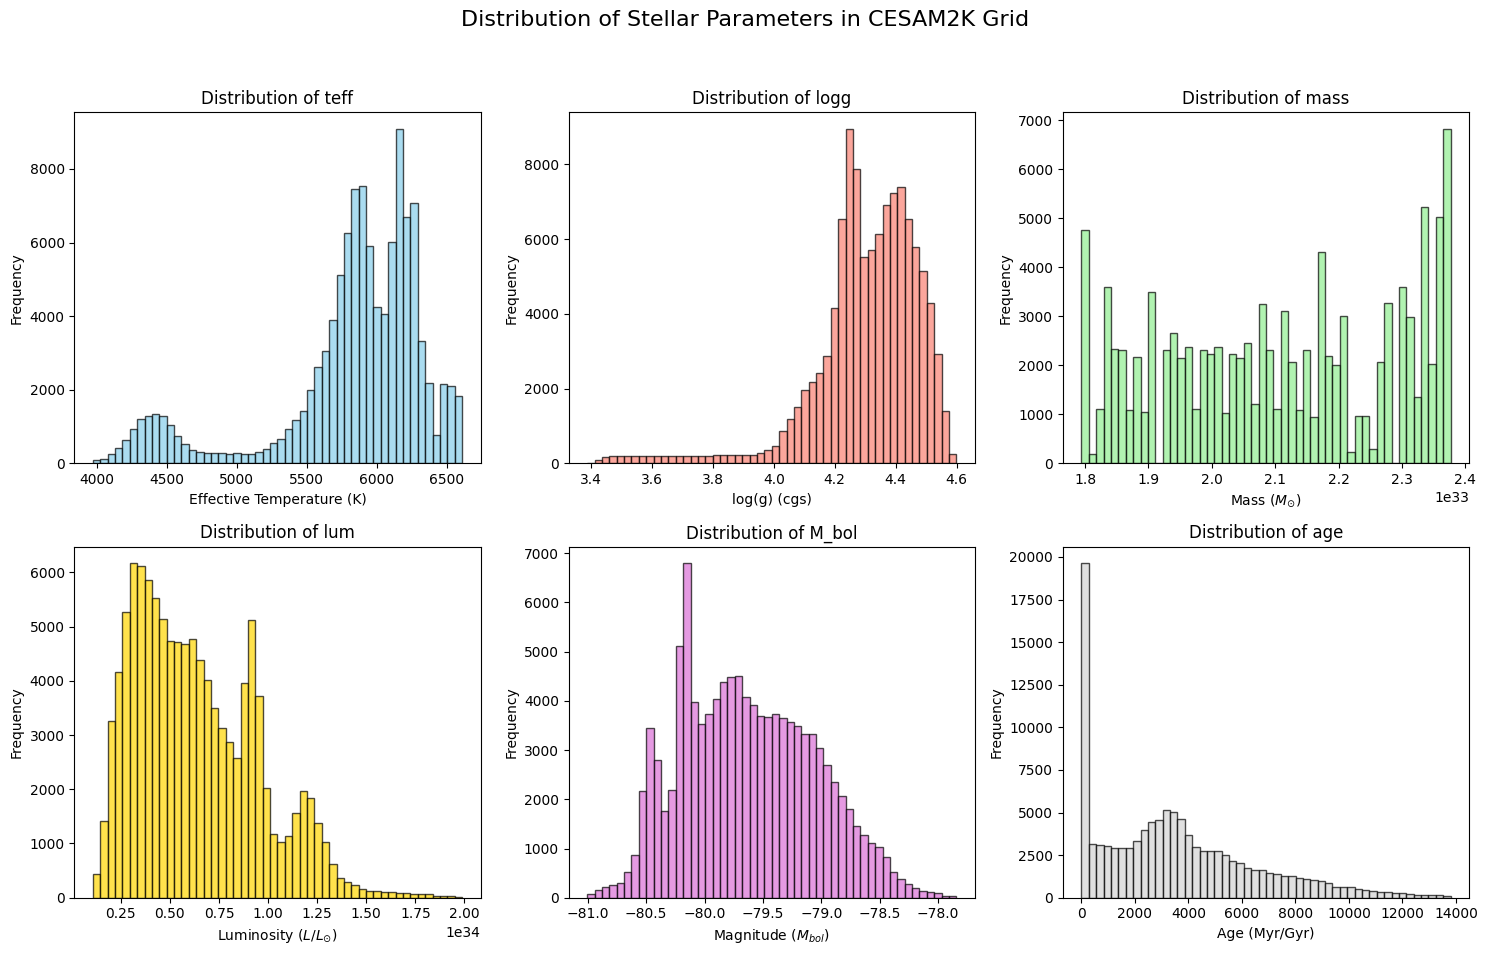

In [44]:
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_grid_histograms(file_path):
    all_data = []
    
    with h5py.File(file_path, 'r') as f:
        # Identify all track groups
        tracks = [k for k in f.keys() if k.startswith('grid_')]
        print(f"Reading {len(tracks)} tracks...")

        for track in tracks:
            path = f"{track}/global"
            if path in f:
                # We only pull the columns we need for the histograms to save memory
                keys_to_pull = ['teff', 'logg', 'lum', 'mass', 'age']
                track_dict = {k: f[path][k][:] for k in keys_to_pull if k in f[path]}
                all_data.append(pd.DataFrame(track_dict))

    # Combine data
    df = pd.concat(all_data, ignore_index=True)
    
    # Calculate M_bol (Absolute Bolometric Magnitude)
    if 'lum' in df.columns:
        df['M_bol'] = 4.74 - 2.5 * np.log10(df['lum'])

    # Setup the figure
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Distribution of Stellar Parameters in CESAM2K Grid', fontsize=16)
    
    # List of parameters to plot
    params = [
        ('teff', 'Effective Temperature (K)', 'skyblue'),
        ('logg', 'log(g) (cgs)', 'salmon'),
        ('mass', 'Mass ($M_{\odot}$)', 'lightgreen'),
        ('lum', 'Luminosity ($L/L_{\odot}$)', 'gold'),
        ('M_bol', 'Magnitude ($M_{bol}$)', 'orchid'),
        ('age', 'Age (Myr/Gyr)', 'lightgrey')
    ]

    for ax, (col, label, color) in zip(axes.flatten(), params):
        if col in df.columns:
            ax.hist(df[col].dropna(), bins=50, color=color, edgecolor='black', alpha=0.7)
            ax.set_xlabel(label)
            ax.set_ylabel('Frequency')
            ax.set_title(f'Distribution of {col}')
        else:
            ax.set_visible(False)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('grid_histograms.png')
    print("Histograms saved as 'grid_histograms.png'")
    
    return df

# Run the plotting function
df_all = plot_grid_histograms('models/grid_v0.1_ov0-plato.hdf5')